# Codveda Technology

### Role : Data Analytics
### Name : DOEUN Bunheng
### ID   :- CV/A1/86646
### Date : 16/08/2026

# Task 1: Data Cleaning and Preprocessing





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Feature Explaination for 1) iris
| Column         | Meaning                                     |
| -------------- | ------------------------------------------- |
| `sepal_length` | Length of the sepal, usually in centimeters |
| `sepal_width`  | Width of the sepal                          |
| `petal_length` | Length of the petal                         |
| `petal_width`  | Width of the petal                          |
| `species`      | Type of Iris flower                         |


In [2]:
df0 = pd.read_csv("1) iris.csv")
df0.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df0.shape

(150, 5)

In [4]:
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [5]:
df0["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
df0.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
df0.duplicated().sum()

np.int64(3)

In [8]:
df0.drop_duplicates(inplace=True)

In [9]:
display(df0["species"].value_counts())
print("The dataset iris has duplicated on the category virginica one duplicate and setosa 2 duplicates.")

species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64

The dataset iris has duplicated on the category virginica one duplicate and setosa 2 duplicates.


In [10]:
df0.to_csv(
    "cleaned_iris_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Feature Explanation for 2) :Stock Prices Data Set

This dataset contains daily stock price information. Here's a breakdown of each feature:

*   **symbol**: This column represents the unique ticker symbol of the company whose stock data is being recorded (e.g., 'AAL' for American Airlines, 'AAPL' for Apple).
*   **date**: This column indicates the specif[link text](https://)ic date on which the stock price data was recorded. It's in `YYYY-MM-DD` format.
*   **open**: This is the price of the stock at the beginning of the trading day.
*   **high**: This is the highest price the stock reached during that trading day.
*   **low**: This is the lowest price the stock fell to during that trading day.
*   **close**: This is the final price of the stock when the trading day concluded.
*   **volume**: This indicates the total number of shares of the stock that were traded during that particular trading day. Higher volume often signifies greater market interest or activity.

In [11]:
df = pd.read_csv("2) Stock Prices Data Set.csv")
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 32.8 MB


In [13]:
df.shape

(497472, 7)

### Identify and handle missing values

In [14]:
print("Missing values before handling:")
df.isnull().sum()

Missing values before handling:


symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

### Remove duplicate rows

In [15]:
print(f"Before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"After removal: {df.duplicated().sum()}")

Before removal: 0
After removal: 0


### Standardize inconsistent data formats

In [16]:
print(f"Data type of 'date' column before conversion: {df['date'].dtype}")
df['date'] = pd.to_datetime(df['date'])
print(f"Data type of 'date' column after conversion: {df['date'].dtype}")
display(df.head())

Data type of 'date' column before conversion: str
Data type of 'date' column after conversion: datetime64[us]


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [17]:
rows_before = len(df)
df = df.dropna(subset = ['open','high','low']).copy()
rows_after = len(df)
print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before: 497472
Rows after: 497461
Rows removed: 11




##### Why did I handle missing value by remove rows?

##### Missing values in the open, high, and low columns were handled by removing the affected rows. Since only a small number of observations were incomplete and these columns represent actual market prices, removal was preferred over imputation to avoid introducing artificial stock-price values.

In [18]:
# check missing value again
df.isnull().sum()


symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [19]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.day_name()

In [20]:
df.head()

,symbol,date,open,high,low,close,volume,year,month,day,day_of_week
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2014,1,2,Thursday
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,2014,1,2,Thursday
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,2014,1,2,Thursday
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2014,1,2,Thursday
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2014,1,2,Thursday


In [21]:
df['month'] = df['date'].dt.strftime('%B')

display(df.head())
df.info()

,symbol,date,open,high,low,close,volume,year,month,day,day_of_week
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2014,January,2,Thursday
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,2014,January,2,Thursday
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,2014,January,2,Thursday
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2014,January,2,Thursday
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2014,January,2,Thursday


<class 'pandas.DataFrame'>
Index: 497461 entries, 0 to 497471
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   symbol       497461 non-null  str           
 1   date         497461 non-null  datetime64[us]
 2   open         497461 non-null  float64       
 3   high         497461 non-null  float64       
 4   low          497461 non-null  float64       
 5   close        497461 non-null  float64       
 6   volume       497461 non-null  int64         
 7   year         497461 non-null  int32         
 8   month        497461 non-null  str           
 9   day          497461 non-null  int32         
 10  day_of_week  497461 non-null  str           
dtypes: datetime64[us](1), float64(4), int32(2), int64(1), str(3)
memory usage: 49.6 MB


In [22]:
df.to_csv(
    "cleaned_stock_price_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Feature Explaination :3) Sentiment dataset




| Feature        | Simple meaning               | Use                     |
| -------------- | ---------------------------- | ----------------------- |
| `Unnamed: 0.1` | Extra row index              |  Remove                |
| `Unnamed: 0`   | Extra row index              |  Remove                |
| `Text`         | Actual social-media post     |  NLP / sentiment       |
| `Sentiment`    | Emotion or sentiment label   |  Main target/analysis  |
| `Timestamp`    | Exact post date and time     |  Time analysis         |
| `User`         | User/account name            |  Mostly for reference |
| `Platform`     | Twitter, Facebook, Instagram |  Compare platforms     |
| `Hashtags`     | Topics/tags of the post      |  Topic analysis        |
| `Retweets`     | Number of shares/reposts     |  Engagement            |
| `Likes`        | Number of likes              |  Engagement            |
| `Country`      | Country of the post/user     |  Location analysis     |
| `Year`         | Year posted                  |  Time analysis         |
| `Month`        | Month posted                 |  Time analysis         |
| `Day`          | Day of month                 |  Time analysis         |
| `Hour`         | Hour posted                  |  Engagement by time    |


In [23]:
df1 = pd.read_csv("3) Sentiment dataset.csv")
df1.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [24]:
df1.shape

(732, 15)

In [25]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 225.0 KB


We have:

Unnamed: 0,
Unnamed: 0.1

Those are unnecessary index columns.

In [26]:
# Remove unnecessary columns

df1 = df1.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])


The columns Unnamed: 0.1 and Unnamed: 0 were removed because they were redundant index columns and did not contain useful analytical information.

In [27]:
df1.shape

(732, 13)

In [28]:
df1.columns

Index(['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='str')

In [29]:
# Check missing values

df1.isnull().sum()

Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

In [30]:
# Total missing values in the whole dataset
df1.isnull().sum().sum()

np.int64(0)

Missing values were checked across all columns. No missing values were found in the dataset, so no imputation or row removal was required.

In [31]:
# Check duplicate rows

df1.duplicated().sum()

np.int64(20)

In [32]:
# Show all rows involved in duplication
duplicate_rows = df1[df1.duplicated(keep=False)]

duplicate_rows

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
265,"Proudly scaling the peaks of achievement, a m...",Proud,2020-01-05 08:45:00,PeakConqueror,Twitter,#Proud #ScalingPeaks,23.0,46.0,USA,2020,1,5,8
266,"Embraced by the hopeful dawn, a gardener sowi...",Hopeful,2022-07-17 06:15:00,DawnGardener,Instagram,#Hopeful #SeedsOfOptimism,14.0,28.0,UK,2022,7,17,6
267,"A playful escapade in the carnival of life, c...",Playful,2018-08-22 17:20:00,CarnivalDreamer,Facebook,#Playful #CarnivalEscapade,24.0,48.0,Australia,2018,8,22,17
268,"Floating on clouds of inspiration, an artist ...",Inspired,2021-12-08 14:30:00,SkyArtist,Twitter,#Inspired #CloudsOfCreativity,18.0,36.0,India,2021,12,8,14
269,"Navigating the river of contentment, a serene...",Contentment,2019-04-27 09:50:00,RiverNavigator,Instagram,#Contentment #TranquilWaters,20.0,40.0,Canada,2019,4,27,9
270,"With empathy as a lantern, wandering through ...",Empathetic,2023-09-03 21:40:00,LanternWanderer,Facebook,#Empathetic #LanternOfCompassion,16.0,32.0,USA,2023,9,3,21
271,"A free spirit soaring on the wings of dreams,...",Free-spirited,2020-06-10 10:05:00,DreamSoarer,Twitter,#FreeSpirit #WingsOfDreams,22.0,44.0,UK,2020,6,10,10
272,"Bathed in the golden hues of gratefulness, a ...",Grateful,2022-04-01 18:30:00,SunsetAdmirer,Instagram,#Grateful #GoldenHues,19.0,38.0,Australia,2022,4,1,18
273,"Confident strides in the dance of life, a bal...",Confident,2021-01-15 13:00:00,DanceStrider,Facebook,#Confident #DanceOfLife,23.0,46.0,Canada,2021,1,15,13
274,"Hopeful whispers of wind, carrying the promis...",Hopeful,2023-05-06 07:20:00,WindWhisperer,Twitter,#Hopeful #BrighterTomorrows,15.0,30.0,India,2023,5,6,7


In [33]:
# Remove duplicate rows
df1 = df1.drop_duplicates()

In [34]:
df1.shape

(712, 13)

In [35]:
# verify duplicate again

df1.duplicated().sum()

np.int64(0)

##### Check inconsistent text formatting

Now we should inspect columns such as:

Sentiment,
Platform,
Country,
User,
Hashtags,
Text

Start with Platform because it is easy to understand.

In [36]:
# Check unique platform values
df1["Platform"].unique()

<ArrowStringArray>
[' Twitter  ', ' Instagram ', ' Facebook ', ' Twitter ']
Length: 4, dtype: str

In [37]:
# Count each platform value
df1["Platform"].value_counts()

Platform
Instagram     252
Facebook      224
Twitter       122
Twitter       114
Name: count, dtype: int64

Platform column currently has 4 values:

' Twitter  ',
' Instagram ',
' Facebook ',
' Twitter '

But logically there should only be 3 platforms:

Twitter,
Instagram,
Facebook

The two Twitter values look the same on screen, but one contains different extra spaces. Pandas therefore treats them as separate categories.

###### Clean the Platform column

In [38]:
# Remove leading and trailing spaces
df1["Platform"] = df1["Platform"].str.strip()

In [39]:
df1["Platform"].unique()

<ArrowStringArray>
['Twitter', 'Instagram', 'Facebook']
Length: 3, dtype: str

In [40]:
df1["Platform"].value_counts()

Platform
Instagram    252
Twitter      236
Facebook     224
Name: count, dtype: int64

The Platform column contained inconsistent whitespace, causing Twitter to appear as multiple categories. Leading and trailing spaces were removed using str.strip(). After standardization, the dataset contained three unique platforms: Instagram, Twitter, and Facebook.

###### Check Country formatting

In [41]:
# Check unique country values before cleaning
df1["Country"].unique()

<ArrowStringArray>
[  ' USA      ',   ' Canada   ', ' USA        ',   ' UK       ',
  ' Australia ',   ' India    ',     ' USA    ',          'USA',
  ' Canada    ',  ' USA       ',
 ...
     ' Norway ',   ' Colombia ',    ' Ireland ',    ' Jamaica ',
      ' Kenya ',   ' Scotland ',   ' Thailand ',         ' USA',
      ' Canada',          ' UK']
Length: 115, dtype: str

In [42]:
# Count the number of unique country values
df1["Country"].nunique()

115

In [43]:
# Count posts for each country
df1["Country"].value_counts()

Country
USA           59
USA           51
UK            49
Canada        44
Australia     36
              ..
Ireland        1
Jamaica        1
Kenya          1
Scotland       1
Thailand       1
Name: count, Length: 115, dtype: int64

###### Clean the Country column

In [44]:
# Remove leading and trailing spaces from Country
df1["Country"] = df1["Country"].str.strip()

In [45]:
# Check unique countries after cleaning
df1["Country"].nunique()

33

In [46]:
# Count posts for each country after cleaning
df1["Country"].value_counts()

Country
USA               184
UK                140
Canada            132
Australia          70
India              68
Brazil             17
France             16
Japan              15
Germany            14
Italy              11
South Africa        6
Greece              5
Spain               5
Netherlands         4
Sweden              2
Portugal            2
Switzerland         2
Belgium             2
Denmark             2
Czech Republic      2
Austria             1
Jordan              1
Peru                1
Maldives            1
China               1
Cambodia            1
Norway              1
Colombia            1
Ireland             1
Jamaica             1
Kenya               1
Scotland            1
Thailand            1
Name: count, dtype: int64

In [47]:
df1["Country"].unique()

<ArrowStringArray>
[           'USA',         'Canada',             'UK',      'Australia',
          'India',         'France',         'Brazil',          'Japan',
         'Greece',        'Germany',         'Sweden',          'Italy',
    'Netherlands',   'South Africa',          'Spain',       'Portugal',
    'Switzerland',        'Austria',        'Belgium',        'Denmark',
 'Czech Republic',         'Jordan',           'Peru',       'Maldives',
          'China',       'Cambodia',         'Norway',       'Colombia',
        'Ireland',        'Jamaica',          'Kenya',       'Scotland',
       'Thailand']
Length: 33, dtype: str

The Country column contained many inconsistent values caused by leading and trailing whitespace. This caused the same country, such as USA and Canada, to be treated as multiple categories. The whitespace was removed using str.strip() to standardize the country names.

##### Check Sentiment

Now let's inspect the Sentiment column before cleaning it.




In [48]:
# Number of unique sentiment values
df1["Sentiment"].nunique()

279

In [49]:
# Check unique sentiment values
df1["Sentiment"].unique()

<ArrowStringArray>
[   ' Positive  ',    ' Negative  ',    ' Neutral   ', ' Anger        ',
 ' Fear         ', ' Sadness      ', ' Disgust      ', ' Happiness    ',
 ' Joy          ', ' Love         ',
 ...
      ' Disgust ',       ' Relief ',     ' Positive ',  ' Embarrassed ',
  ' Mischievous ',          ' Sad ',         ' Hate ',          ' Bad ',
      ' Neutral ',        ' Happy ']
Length: 279, dtype: str

In [50]:
# Count each sentiment
df1["Sentiment"].value_counts()

Sentiment
Positive         44
Joy              42
Excitement       32
Neutral          14
Happy            14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64

##### Clean Sentiment

In [51]:
# Remove leading and trailing spaces from Sentiment
df1["Sentiment"] = df1["Sentiment"].str.strip()


In [52]:
# Number of unique sentiments after cleaning
df1["Sentiment"].nunique()

191

In [53]:
df1["Sentiment"].value_counts()

Sentiment
Positive                45
Joy                     44
Excitement              37
Neutral                 18
Contentment             18
                        ..
Creative Inspiration     1
Runway Creativity        1
Ocean's Freedom          1
Whispers of the Past     1
Relief                   1
Name: count, Length: 191, dtype: int64

The Sentiment column initially contained 279 unique values because several labels had inconsistent leading and trailing whitespace. After applying str.strip(), the number of unique sentiment categories decreased to 191. Only formatting inconsistencies were corrected; the original sentiment meanings were preserved.

###### clean the remaining text columns

In [54]:
# Remove leading and trailing spaces from remaining text columns
text_columns = ["Text", "User", "Hashtags"]

for column in text_columns:
    df1[column] = df1[column].str.strip()

In [55]:
df1[["Text", "User", "Hashtags"]].head()

,Text,User,Hashtags
0,Enjoying a beautiful day at the park!,User123,#Nature #Park
1,Traffic was terrible this morning.,CommuterX,#Traffic #Morning
2,Just finished an amazing workout! 💪,FitnessFan,#Fitness #Workout
3,Excited about the upcoming weekend getaway!,AdventureX,#Travel #Adventure
4,Trying out a new recipe for dinner tonight.,ChefCook,#Cooking #Food


##### convert Timestamp to datetime

In [56]:
# Convert Timestamp from object to datetime
df1["Timestamp"] = pd.to_datetime(df1["Timestamp"])

In [57]:
df1["Timestamp"].dtype

dtype('<M8[us]')

In [58]:
df1[["Timestamp", "Year", "Month", "Day", "Hour"]].head()

,Timestamp,Year,Month,Day,Hour
0,2023-01-15 12:30:00,2023,1,15,12
1,2023-01-15 08:45:00,2023,1,15,8
2,2023-01-15 15:45:00,2023,1,15,15
3,2023-01-15 18:20:00,2023,1,15,18
4,2023-01-15 19:55:00,2023,1,15,19


The Timestamp column was converted from an object data type to datetime64[ns]. This allows Python to correctly recognize and analyze the date and time information.

In [59]:
# 1. Ensure Timestamp is in datetime format
df1["Timestamp"] = pd.to_datetime(df1["Timestamp"])

# 2. Overwrite the "Month" column directly
df1["Month"] = df1["Timestamp"].dt.strftime("%b")

# Check your updated dataframe
print(df1[["Timestamp", "Month"]].head())

            Timestamp Month
0 2023-01-15 12:30:00   Jan
1 2023-01-15 08:45:00   Jan
2 2023-01-15 15:45:00   Jan
3 2023-01-15 18:20:00   Jan
4 2023-01-15 19:55:00   Jan


In [60]:
df1.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,Jan,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,Jan,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,Jan,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,Jan,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,Jan,15,19


##### validate all date components

Now we should make sure every row, not just the first five, has correct Year, Month, Day, and Hour values.

In [61]:
# Validate Year, Month, Day, and Hour against Timestamp

year_errors = (df1["Timestamp"].dt.year != df1["Year"]).sum()
day_errors = (df1["Timestamp"].dt.day != df1["Day"]).sum()
hour_errors = (df1["Timestamp"].dt.hour != df1["Hour"]).sum()

print("Year errors:", year_errors)
print("Day errors:", day_errors)
print("Hour errors:", hour_errors)

Year errors: 0
Day errors: 0
Hour errors: 0


##### check whether there are impossible negative values:

In [62]:
# Check for negative Likes and Retweets
negative_likes = (df1["Likes"] < 0).sum()
negative_retweets = (df1["Retweets"] < 0).sum()

print("Negative Likes:", negative_likes)
print("Negative Retweets:", negative_retweets)

Negative Likes: 0
Negative Retweets: 0


In [63]:
# Convert Likes and Retweets from float to integer
df1["Likes"] = df1["Likes"].astype(int)
df1["Retweets"] = df1["Retweets"].astype(int)

In [64]:
df1[["Likes", "Retweets"]].dtypes

Likes       int64
Retweets    int64
dtype: object

#### Final dataset verification

In [65]:
# Final verification of cleaned dataset

print("Final dataset shape:", df1.shape)

print("\nMissing values:")
print(df1.isnull().sum())

print("\nDuplicate rows:")
print(df1.duplicated().sum())

print("\nData types:")
print(df1.dtypes)

Final dataset shape: (712, 13)

Missing values:
Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

Duplicate rows:
2

Data types:
Text                    str
Sentiment               str
Timestamp    datetime64[us]
User                    str
Platform                str
Hashtags                str
Retweets              int64
Likes                 int64
Country                 str
Year                  int64
Month                   str
Day                   int64
Hour                  int64
dtype: object


In [66]:
df1 = df1.drop_duplicates()

In [67]:
print("Duplicate rows:", df1.duplicated().sum())
print("Final shape:", df1.shape)

Duplicate rows: 0
Final shape: (710, 13)


In [68]:
print(df1["Month"].unique())
print(df1["Month"].value_counts())

<ArrowStringArray>
['Jan', 'Feb', 'Mar', 'May', 'Aug', 'Jun', 'Nov', 'Apr', 'Sep', 'Jul', 'Oct',
 'Dec']
Length: 12, dtype: str
Month
Feb    85
Jan    78
Aug    75
Sep    74
Jun    70
Jul    60
Apr    49
Oct    47
Nov    46
May    45
Mar    44
Dec    37
Name: count, dtype: int64


In [69]:
# Check whether Month matches Timestamp
month_errors = (
    df1["Timestamp"].dt.strftime("%b") != df1["Month"]
).sum()

print("Month errors:", month_errors)

Month errors: 0


In [70]:
month_order = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

df1["Month"] = pd.Categorical(
    df1["Month"],
    categories=month_order,
    ordered=True
)

In [71]:
print("Final dataset shape:", df1.shape)

print("\nMissing values:")
print(df1.isnull().sum())

print("\nDuplicate rows:")
print(df1.duplicated().sum())

print("\nData types:")
print(df1.dtypes)

print("\nPlatforms:")
print(df1["Platform"].unique())

print("\nNumber of countries:")
print(df1["Country"].nunique())

print("\nNumber of sentiments:")
print(df1["Sentiment"].nunique())

Final dataset shape: (710, 13)

Missing values:
Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

Duplicate rows:
0

Data types:
Text                    str
Sentiment               str
Timestamp    datetime64[us]
User                    str
Platform                str
Hashtags                str
Retweets              int64
Likes                 int64
Country                 str
Year                  int64
Month              category
Day                   int64
Hour                  int64
dtype: object

Platforms:
<ArrowStringArray>
['Twitter', 'Instagram', 'Facebook']
Length: 3, dtype: str

Number of countries:
33

Number of sentiments:
191


In [72]:
df1.to_csv(
    "cleaned_sentiment_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

#Conclusion: The raw sentiment dataset was cleaned and preprocessed successfully.
# Two unnecessary index columns were removed, missing values were checked,
# duplicate records were removed, inconsistent whitespace in categorical and
# text fields was standardized, the Timestamp column was converted to datetime
# format, time-related columns were validated, and Likes and Retweets
# were converted to appropriate integer data types. The final cleaned dataset
# contains 710 rows and 13 useful features, with no missing values or duplicate records.#

Cleaned dataset saved successfully!




```
# This is formatted as code
```

# Task 2: Exploratory Data Analysis (EDA)

In [73]:
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams["figure.figsize"] = (10, 6)

## 1) iris

In [74]:
# Load data clean
df_eda0 = pd.read_csv("cleaned_iris_dataset.csv")
df_eda0.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.10,3.50,1.40,0.20,setosa
1,4.90,3.00,1.40,0.20,setosa
2,4.70,3.20,1.30,0.20,setosa
3,4.60,3.10,1.50,0.20,setosa
4,5.00,3.60,1.40,0.20,setosa


In [75]:
# summary statistics (Mean, Median, Mode,Std)
# Identify numerical features
num_cols = df_eda0.select_dtypes(include=[np.number]).columns.tolist()

# Compute summary statistics table
summary_df0 = df_eda0[num_cols].describe().T
summary_df0["median"] = df_eda0[num_cols].median()
summary_df0["mode"] = df_eda0[num_cols].mode().iloc[0]

stat_columns = ["count", "mean", "median", "mode", "std", "min", "25%", "50%", "75%", "max"]
summary_df0 = summary_df0[[col for col in stat_columns if col in summary_df0.columns]]
display(summary_df0)

,count,mean,median,mode,std,min,25%,50%,75%,max
sepal_length,147.00,5.86,5.80,5.00,0.83,4.30,5.10,5.80,6.40,7.90
sepal_width,147.00,3.06,3.00,3.00,0.44,2.00,2.80,3.00,3.30,4.40
petal_length,147.00,3.78,4.40,1.40,1.76,1.00,1.60,4.40,5.10,6.90
petal_width,147.00,1.21,1.30,0.20,0.76,0.10,0.30,1.30,1.80,2.50


In [76]:
# Categorical summary
cat_cols = df_eda0.select_dtypes(include=["object", "category"]).columns.tolist()
if len(cat_cols) > 0:
    print("\n--- Categorical Summary ---")
    display(df_eda0[cat_cols].describe())


--- Categorical Summary ---


C:\Users\Bunheng\AppData\Local\Temp\ipykernel_11516\2801142208.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_eda0.select_dtypes(include=["object", "category"]).columns.tolist()


,species
count,147
unique,3
top,versicolor
freq,50


In [77]:
display(df_eda0.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

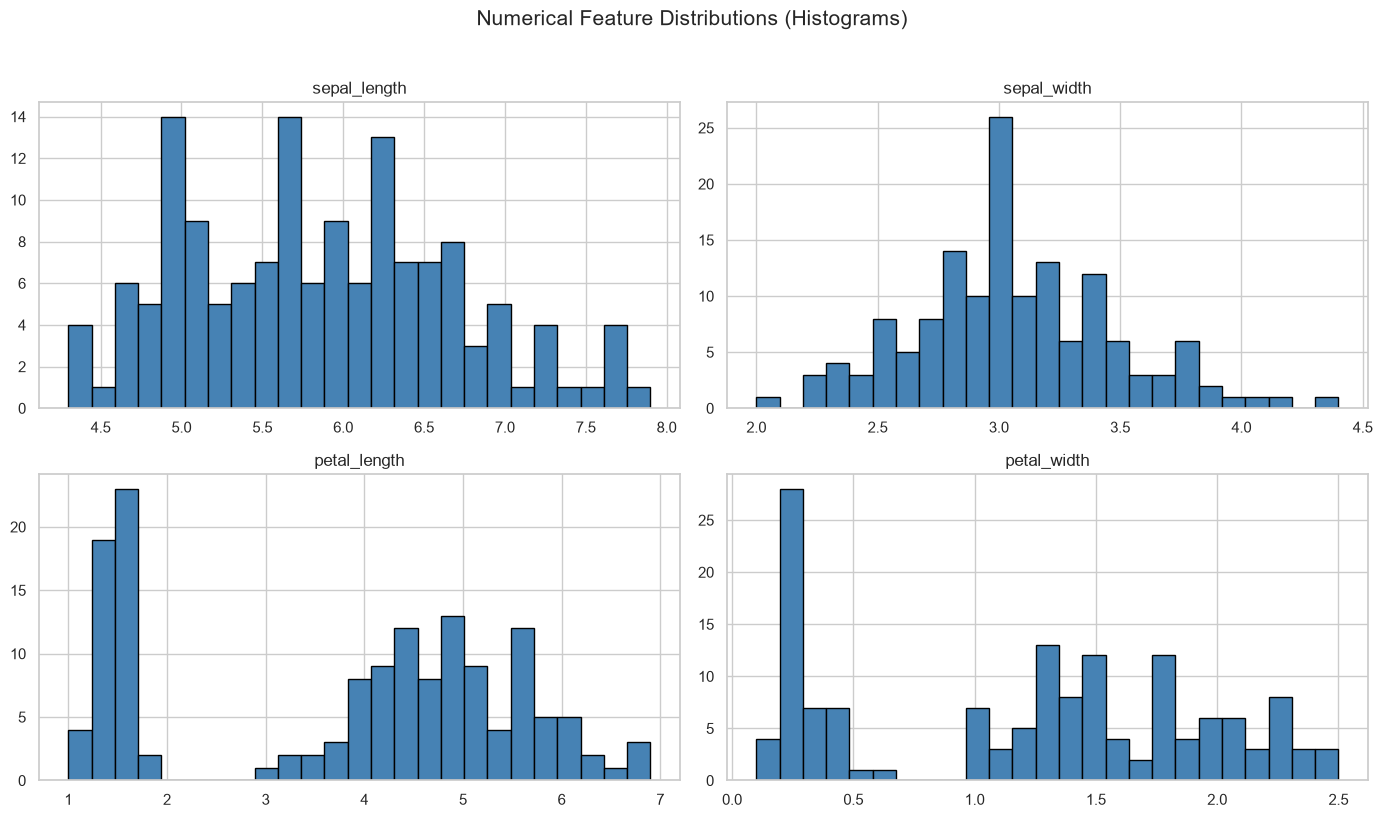

In [78]:
# data distributions & visualizations
# A. Histograms with KDE
key_dist_features = [col for col in ["sepal_length", "sepal_width", "petal_length", "petal_width"] if col in df_eda0.columns]

df_eda0[key_dist_features].hist(bins=25, figsize=(14, 8), color="steelblue", edgecolor="black")
plt.suptitle("Numerical Feature Distributions (Histograms)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


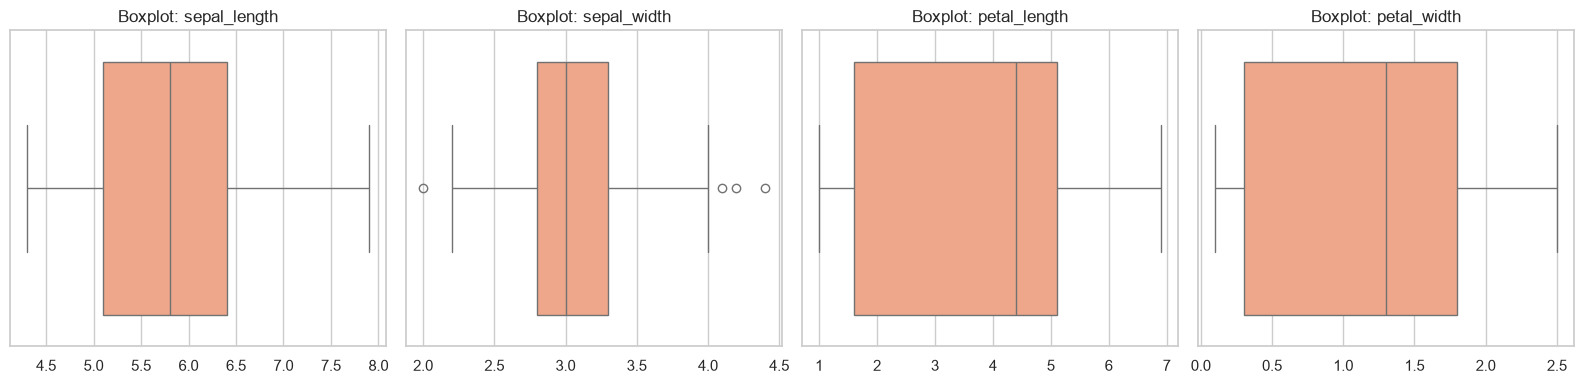

In [79]:

# B. Boxplots (Outlier & Range Inspection)
fig, axes = plt.subplots(1, len(key_dist_features), figsize=(16, 4))
for idx, col in enumerate(key_dist_features):
    sns.boxplot(x=df_eda0[col].dropna(), ax=axes[idx], color="lightsalmon")
    axes[idx].set_title(f"Boxplot: {col}")
    axes[idx].set_xlabel("")

plt.tight_layout()
plt.show()

<Axes: >

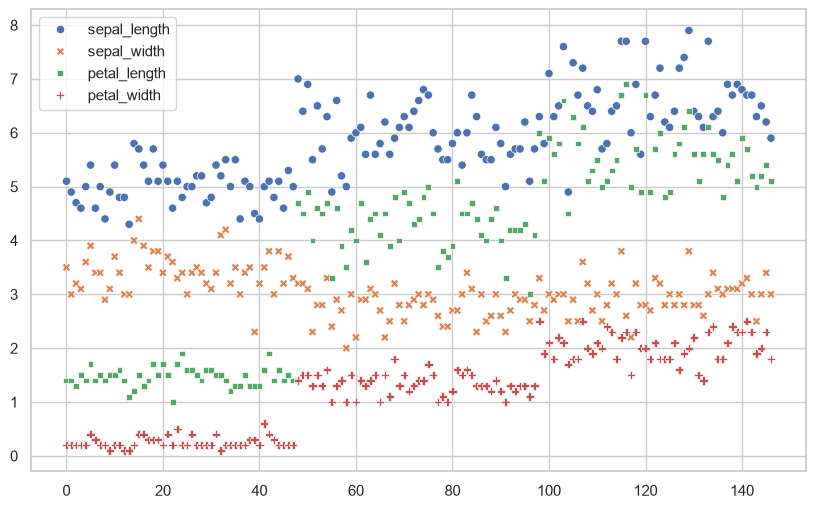

In [80]:
# C. Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(df_eda0)


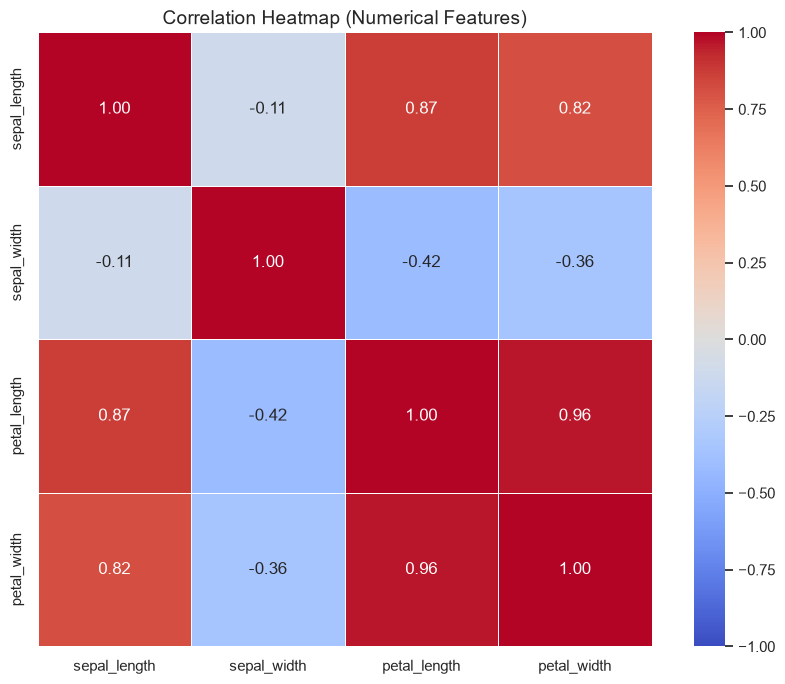

In [81]:
# Feature Correlation Analysis
# Compute Pearson correlation matrix
corr_matrix = df_eda0[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap (Numerical Features)", fontsize=14)
plt.tight_layout()
plt.show()

## 2) Stock Price





In [82]:
df_eda = pd.read_csv("cleaned_stock_price_dataset.csv")
df_eda.head()


,symbol,date,open,high,low,close,volume,year,month,day,day_of_week
0,AAL,2014-01-02,25.07,25.82,25.06,25.36,8998943,2014,January,2,Thursday
1,AAPL,2014-01-02,79.38,79.58,78.86,79.02,58791957,2014,January,2,Thursday
2,AAP,2014-01-02,110.36,111.88,109.29,109.74,542711,2014,January,2,Thursday
3,ABBV,2014-01-02,52.12,52.33,51.52,51.98,4569061,2014,January,2,Thursday
4,ABC,2014-01-02,70.11,70.23,69.48,69.89,1148391,2014,January,2,Thursday


In [83]:
# summary statistics (Mean, Median, Mode,Std)
# Identify numerical features
num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()

# Compute summary statistics table
summary_df = df_eda[num_cols].describe().T
summary_df["median"] = df_eda[num_cols].median()
summary_df["mode"] = df_eda[num_cols].mode().iloc[0]

stat_columns = ["count", "mean", "median", "mode", "std", "min", "25%", "50%", "75%", "max"]
summary_df = summary_df[[col for col in stat_columns if col in summary_df.columns]]

display(summary_df)

,count,mean,median,mode,std,min,25%,50%,75%,max
open,497461.00,86.35,64.97,70.00,101.47,1.62,41.69,64.97,98.41,2044.00
high,497461.00,87.13,65.56,72.00,102.31,1.69,42.09,65.56,99.23,2067.99
low,497461.00,85.55,64.36,77.00,100.57,1.50,41.28,64.36,97.58,2035.11
close,497461.00,86.37,64.98,34.50,101.47,1.59,41.70,64.98,98.42,2049.00
volume,497461.00,4253694.67,2085013.00,1241019.00,8232210.33,101.00,1080183.00,2085013.00,4271999.00,618237630.00
year,497461.00,2015.51,2016.00,2017.00,1.12,2014.00,2015.00,2016.00,2017.00,2017.00
day,497461.00,15.75,16.00,28.00,8.75,1.00,8.00,16.00,23.00,31.00


In [84]:
# Categorical summary
cat_cols = df_eda.select_dtypes(include=["object", "category"]).columns.tolist()
if len(cat_cols) > 0:
    print("\n--- Categorical Summary ---")
    display(df_eda[cat_cols].describe())


--- Categorical Summary ---


C:\Users\Bunheng\AppData\Local\Temp\ipykernel_11516\2826753372.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_eda.select_dtypes(include=["object", "category"]).columns.tolist()


,symbol,date,month,day_of_week
count,497461,497461,497461,497461
unique,505,1007,12,5
top,AAL,2017-12-05,October,Wednesday
freq,1007,505,43614,102757


In [85]:
display(df_eda.columns)

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'year',
       'month', 'day', 'day_of_week'],
      dtype='str')

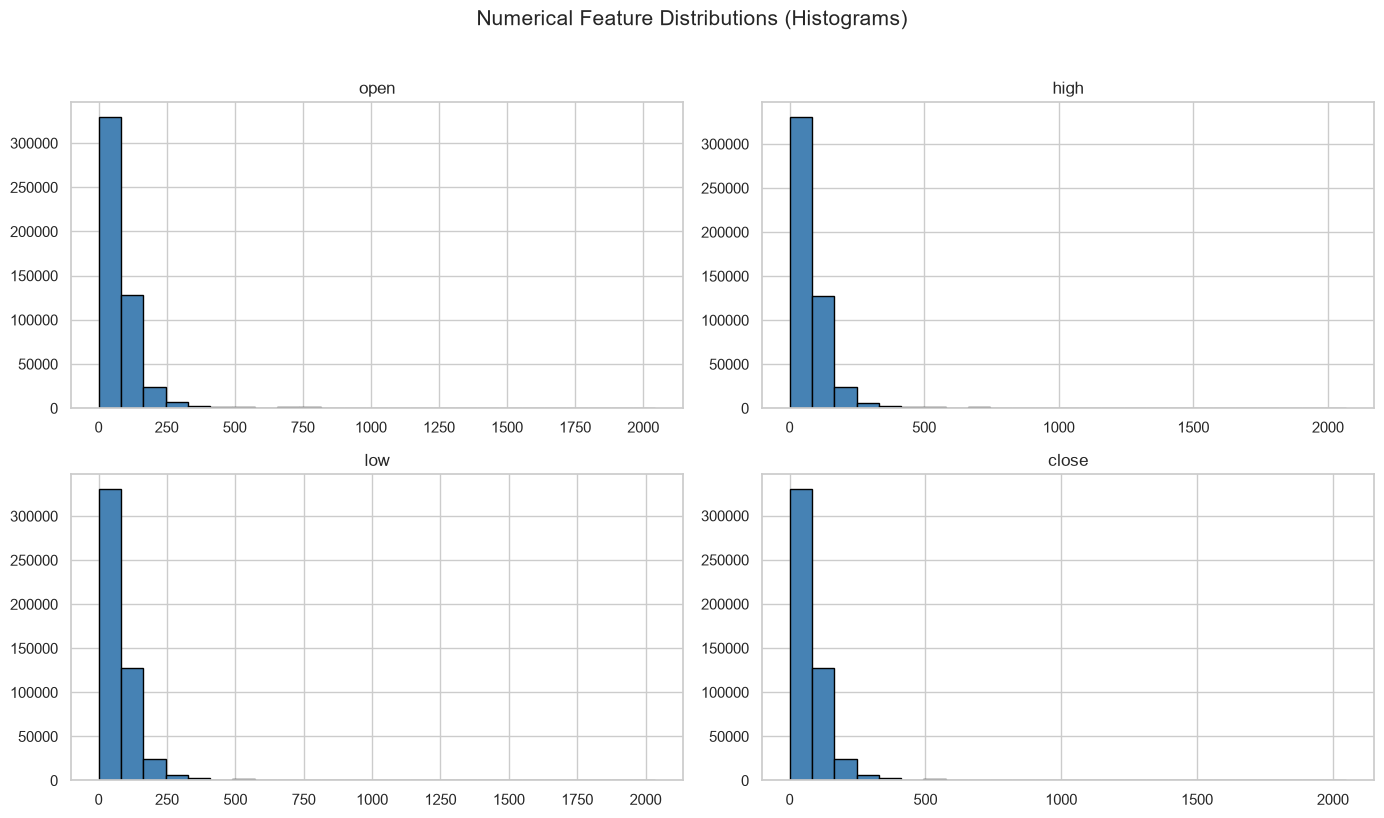

In [86]:
# data distributions & visualizations
# A. Histograms with KDE
key_dist_features = [col for col in ["open", "high", "low", "close"] if col in df_eda.columns]

df_eda[key_dist_features].hist(bins=25, figsize=(14, 8), color="steelblue", edgecolor="black")
plt.suptitle("Numerical Feature Distributions (Histograms)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


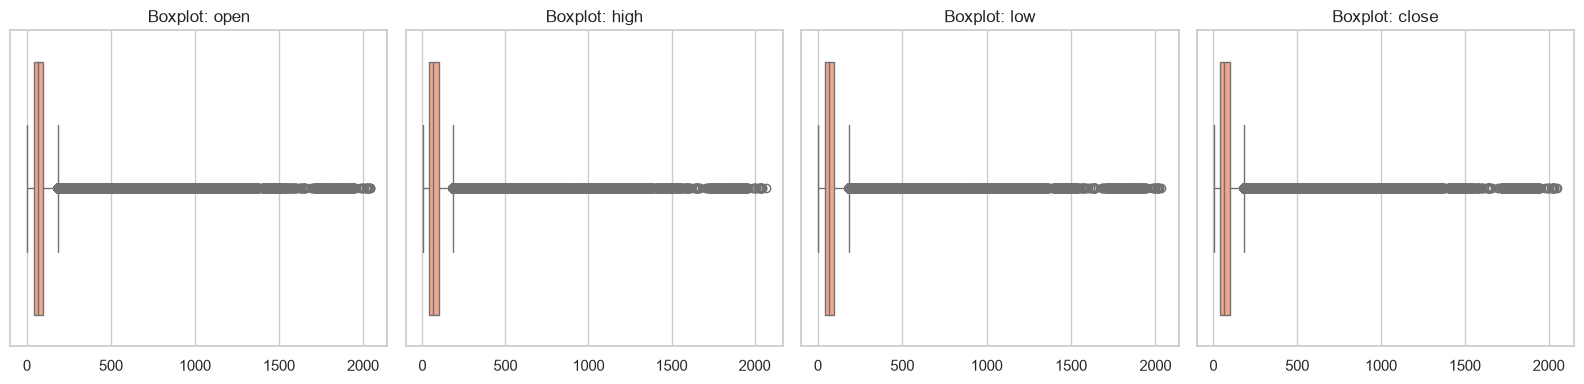

In [87]:

# B. Boxplots (Outlier & Range Inspection)
fig, axes = plt.subplots(1, len(key_dist_features), figsize=(16, 4))
for idx, col in enumerate(key_dist_features):
    sns.boxplot(x=df_eda[col].dropna(), ax=axes[idx], color="lightsalmon")
    axes[idx].set_title(f"Boxplot: {col}")
    axes[idx].set_xlabel("")

plt.tight_layout()
plt.show()

In [88]:
df_eda.shape

(497461, 11)

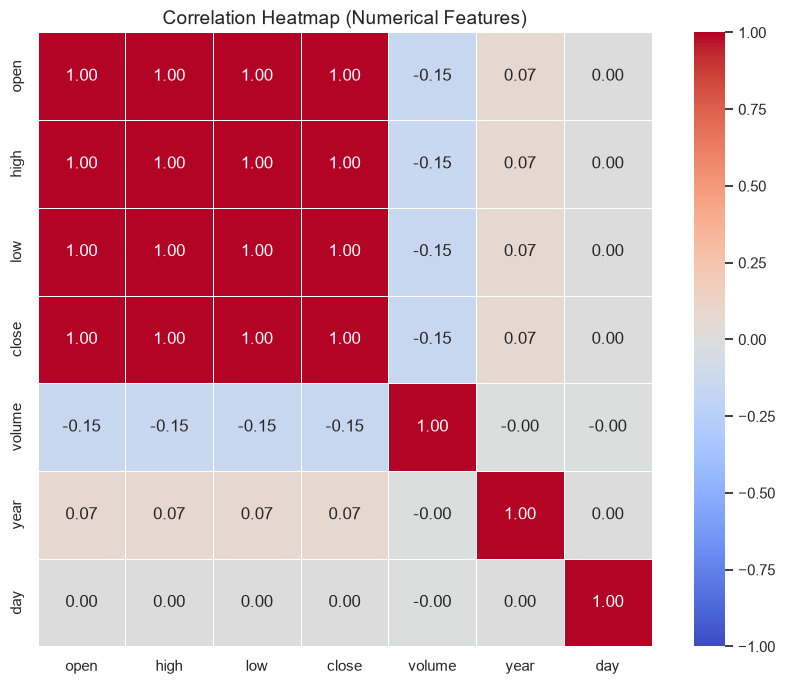

In [89]:
# Feature Correlation Analysis
# Compute Pearson correlation matrix
corr_matrix = df_eda[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap (Numerical Features)", fontsize=14)
plt.tight_layout()
plt.show()

# 3) Sentiment

In [90]:
df_eda1 = pd.read_csv("cleaned_sentiment_dataset.csv")

In [91]:
df_eda1.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,Jan,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,Jan,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,Jan,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,Jan,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,Jan,15,19


In [92]:
df_eda1.shape

(710, 13)

In [93]:
df_eda1.info()

<class 'pandas.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Text       710 non-null    str  
 1   Sentiment  710 non-null    str  
 2   Timestamp  710 non-null    str  
 3   User       710 non-null    str  
 4   Platform   710 non-null    str  
 5   Hashtags   710 non-null    str  
 6   Retweets   710 non-null    int64
 7   Likes      710 non-null    int64
 8   Country    710 non-null    str  
 9   Year       710 non-null    int64
 10  Month      710 non-null    str  
 11  Day        710 non-null    int64
 12  Hour       710 non-null    int64
dtypes: int64(5), str(8)
memory usage: 189.9 KB


In [94]:
# convert the timestamp again

df_eda1["Timestamp"] = pd.to_datetime(df_eda1["Timestamp"])

In [95]:
month_order = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

df_eda1["Month"] = pd.Categorical(
    df_eda1["Month"],
    categories=month_order,
    ordered=True
)

In [96]:
# Final verification

print("Shape:", df_eda1.shape)
print("\nMissing values:", df_eda1.isnull().sum().sum())
print("Duplicates:", df_eda1.duplicated().sum())
print("\nData types:")
print(df_eda1.dtypes)

Shape: (710, 13)

Missing values: 0
Duplicates: 0

Data types:
Text                    str
Sentiment               str
Timestamp    datetime64[us]
User                    str
Platform                str
Hashtags                str
Retweets              int64
Likes                 int64
Country                 str
Year                  int64
Month              category
Day                   int64
Hour                  int64
dtype: object


In [97]:
# Summary statistics for Likes and Retweets
num_cols = df_eda1.select_dtypes(include=[np.number]).columns.tolist()

# Compute summary statistics table
summary_df1 = df_eda1[num_cols].describe().T
summary_df1["median"] = df_eda1[num_cols].median()
summary_df1["mode"] = df_eda1[num_cols].mode().iloc[0]

stat_columns = ["count", "mean", "median", "mode", "std", "min", "25%", "50%", "75%", "max"]
summary_df1 = summary_df1[[col for col in stat_columns if col in summary_df1.columns]]

display(summary_df1)

,count,mean,median,mode,std,min,25%,50%,75%,max
Retweets,710.00,21.55,22.00,22,7.12,5.00,18.00,22.00,25.00,40.00
Likes,710.00,42.98,43.00,45,14.20,10.00,35.00,43.00,50.00,80.00
Year,710.00,2020.48,2021.00,2023,2.83,2010.00,2019.00,2021.00,2023.00,2023.00
Day,710.00,15.49,15.00,15,8.44,1.00,10.00,15.00,22.00,31.00
Hour,710.00,15.60,16.00,14,4.06,0.00,13.00,16.00,19.00,23.00


In [98]:
# Mean
print("Mean Likes:", df_eda1["Likes"].mean())
print("Mean Retweets:", df_eda1["Retweets"].mean())

# Median
print("Median Likes:", df_eda1["Likes"].median())
print("Median Retweets:", df_eda1["Retweets"].median())

# Mode
print("Mode Likes:", df_eda1["Likes"].mode().tolist())
print("Mode Retweets:", df_eda1["Retweets"].mode().tolist())

# Standard deviation
print("Std Likes:", df_eda1["Likes"].std())
print("Std Retweets:", df_eda1["Retweets"].std())

Mean Likes: 42.98169014084507
Mean Retweets: 21.549295774647888
Median Likes: 43.0
Median Retweets: 22.0
Mode Likes: [45]
Mode Retweets: [22]
Std Likes: 14.20268166199127
Std Retweets: 7.117567476408166


In [99]:
# Count posts by platform
platform_counts = df_eda1["Platform"].value_counts()

print(platform_counts)

Platform
Instagram    251
Twitter      236
Facebook     223
Name: count, dtype: int64


In [100]:
# Percentage of posts by platform
platform_percentage = (
    df_eda1["Platform"].value_counts(normalize=True) * 100
).round(2)

print(platform_percentage)

Platform
Instagram   35.35
Twitter     33.24
Facebook    31.41
Name: proportion, dtype: float64


The dataset contains posts from three social-media platforms. Instagram has the highest share at 35.35%, followed by Twitter at 33.24% and Facebook at 31.41%. Overall, the platform distribution is fairly balanced.

In [101]:
# Top 10 countries by number of posts
country_counts = df_eda1["Country"].value_counts().head(10)

print(country_counts)

Country
USA          184
UK           140
Canada       131
Australia     70
India         68
Brazil        17
France        16
Japan         15
Germany       14
Italy         11
Name: count, dtype: int64


In [102]:
country_percentage = (
    df_eda1["Country"].value_counts(normalize=True).head(10) * 100
).round(2)

print(country_percentage)

Country
USA         25.92
UK          19.72
Canada      18.45
Australia    9.86
India        9.58
Brazil       2.39
France       2.25
Japan        2.11
Germany      1.97
Italy        1.55
Name: proportion, dtype: float64


The USA contributes the largest share of posts with 184 records, representing 25.92% of the dataset. The UK and Canada follow with 19.72% and 18.45%, respectively. Australia and India also contribute noticeable shares, while the remaining countries have much smaller representation.

In [103]:
# Top 10 sentiment labels
sentiment_counts = df_eda1["Sentiment"].value_counts().head(10)

print(sentiment_counts)

Sentiment
Positive       45
Joy            44
Excitement     37
Neutral        18
Contentment    18
Gratitude      17
Curiosity      16
Serenity       15
Happy          14
Despair        11
Name: count, dtype: int64


In [104]:
sentiment_percentage = (
    df_eda1["Sentiment"].value_counts(normalize=True).head(10) * 100
).round(2)

print(sentiment_percentage)

Sentiment
Positive      6.34
Joy           6.20
Excitement    5.21
Neutral       2.54
Contentment   2.54
Gratitude     2.39
Curiosity     2.25
Serenity      2.11
Happy         1.97
Despair       1.55
Name: proportion, dtype: float64


Positive is the most frequent sentiment with 45 posts (6.34%), followed closely by Joy with 44 posts (6.20%) and Excitement with 37 posts (5.21%). The remaining sentiment categories occur less frequently. Because the dataset contains 191 unique sentiment labels, the sentiment distribution is highly diverse rather than dominated by only a few classes.

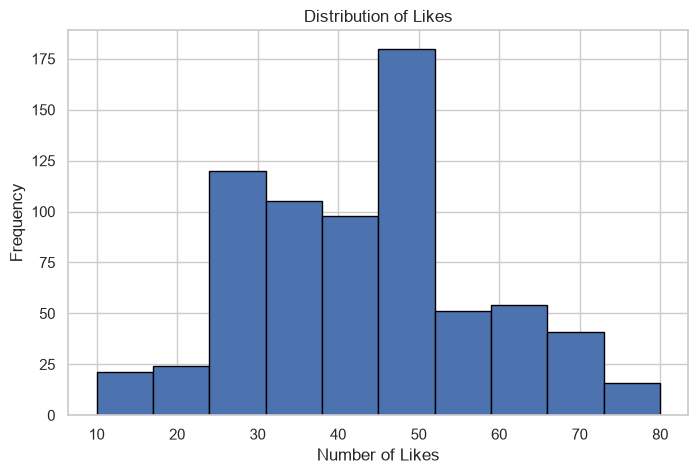

In [105]:
# Histogram of Likes
plt.figure(figsize=(8, 5))

plt.hist(df_eda1["Likes"], bins=10, edgecolor="black")

plt.title("Distribution of Likes")
plt.xlabel("Number of Likes")
plt.ylabel("Frequency")

plt.show()

The histogram shows that most social-media posts received approximately 25 to 55 likes, with the highest concentration around 45 to 50 likes. Very low and very high numbers of likes were less common. The mean and median are very similar, suggesting that the distribution of likes is relatively balanced without strong skewness.

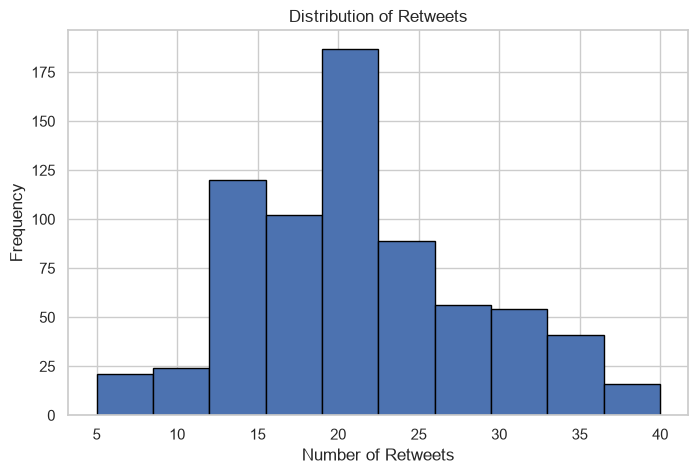

In [106]:
# Histogram of Retweets
plt.figure(figsize=(8, 5))

plt.hist(df_eda1["Retweets"], bins=10, edgecolor="black")

plt.title("Distribution of Retweets")
plt.xlabel("Number of Retweets")
plt.ylabel("Frequency")

plt.show()

The histogram shows that most social-media posts received approximately 13 to 25 retweets, with the highest concentration around 20 retweets. Very low and very high retweet counts were less frequent. The mean and median are very similar, indicating that the distribution is relatively balanced.

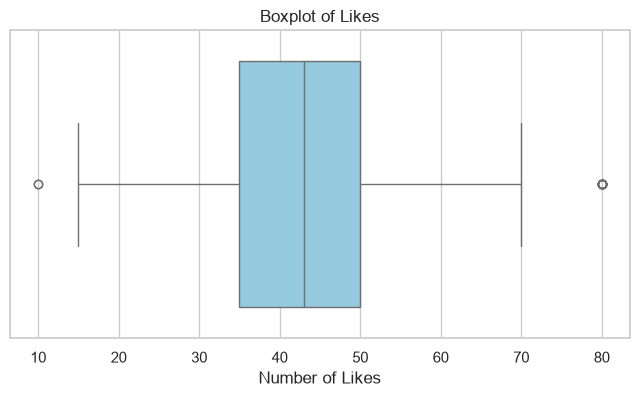

In [107]:
# Boxplot for Likes
plt.figure(figsize=(8, 4))

sns.boxplot(x=df_eda1["Likes"], orient="h", color="skyblue")

plt.title("Boxplot of Likes")
plt.xlabel("Number of Likes")

plt.show()

The boxplot for Likes indicates potential outliers at approximately 10 and 80 likes. Most observations lie between roughly 15 and 70 likes, while the middle 50% of the data falls between 35 and 50 likes.

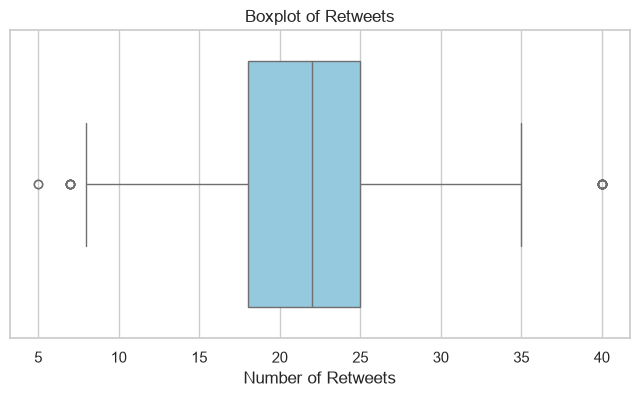

In [108]:
# Boxplot for Retweets
plt.figure(figsize=(8, 4))

sns.boxplot(x=df_eda1["Retweets"], orient="h", color="skyblue")

plt.title("Boxplot of Retweets")
plt.xlabel("Number of Retweets")

plt.show()

The Retweets boxplot shows potential outliers at the lower end, around 5–7 retweets, and at the upper end around 40 retweets. Most observations fall between approximately 8 and 35 retweets.

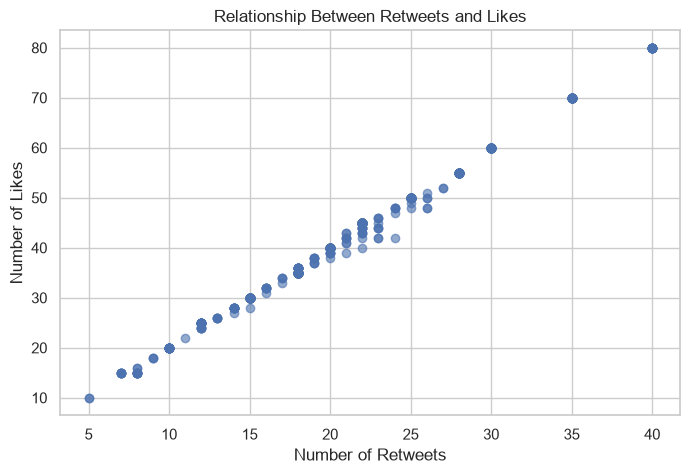

In [109]:
# Scatter plot of Likes vs Retweets
plt.figure(figsize=(8, 5))

plt.scatter(df_eda1["Retweets"], df_eda1["Likes"], alpha=0.6)

plt.title("Relationship Between Retweets and Likes")
plt.xlabel("Number of Retweets")
plt.ylabel("Number of Likes")

plt.show()

In [110]:
correlation = df_eda1["Likes"].corr(df_eda1["Retweets"])

print("Correlation between Likes and Retweets:", correlation)

Correlation between Likes and Retweets: 0.9984702819494389


The scatter plot shows a very strong positive relationship between Retweets and Likes. The Pearson correlation coefficient is approximately 0.998, which is very close to +1. This indicates that posts with more retweets also tend to have more likes in this dataset.

In [111]:
# Select numerical features
numeric_columns = [
    "Likes",
    "Retweets",
    "Year",
    "Day",
    "Hour"
]

# Calculate correlation matrix
correlation_matrix = df_eda1[numeric_columns].corr()

correlation_matrix

,Likes,Retweets,Year,Day,Hour
Likes,1.00,1.00,-0.04,0.02,0.20
Retweets,1.00,1.00,-0.03,0.01,0.20
Year,-0.04,-0.03,1.00,0.03,-0.09
Day,0.02,0.01,0.03,1.00,0.04
Hour,0.20,0.20,-0.09,0.04,1.00


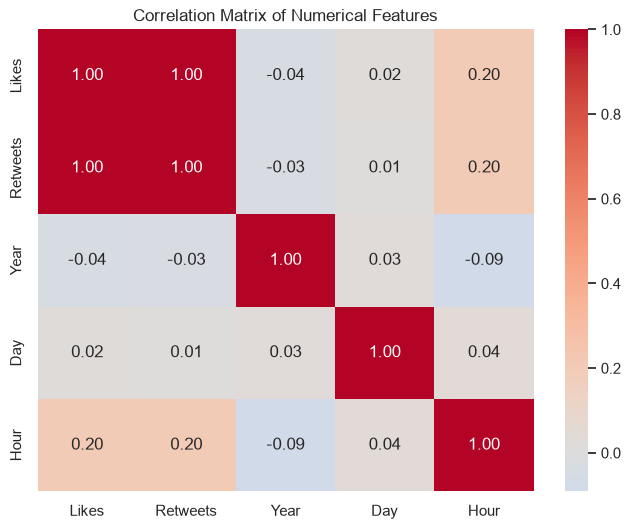

In [112]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

Correlation Analysis: The correlation matrix shows an extremely strong positive relationship between Likes and Retweets, with a Pearson correlation coefficient of approximately 0.998. This indicates that posts receiving more retweets also tend to receive more likes. Hour has a weak positive correlation of approximately 0.20 with both engagement metrics. In contrast, Year and Day show correlations close to zero, suggesting little linear relationship with engagement.

# Task 3: Basic Data Visualization




## 1) iris

In [113]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


output_dir = "iris_visualizations"
os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 11

df = pd.read_csv("cleaned_iris_dataset.csv")

df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
species_col = [c for c in df.columns if any(k in c for k in ["species", "target", "class"])][0]
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()


In [114]:
display(df_eda0.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

C:\Users\Bunheng\AppData\Local\Temp\ipykernel_11516\2579694624.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


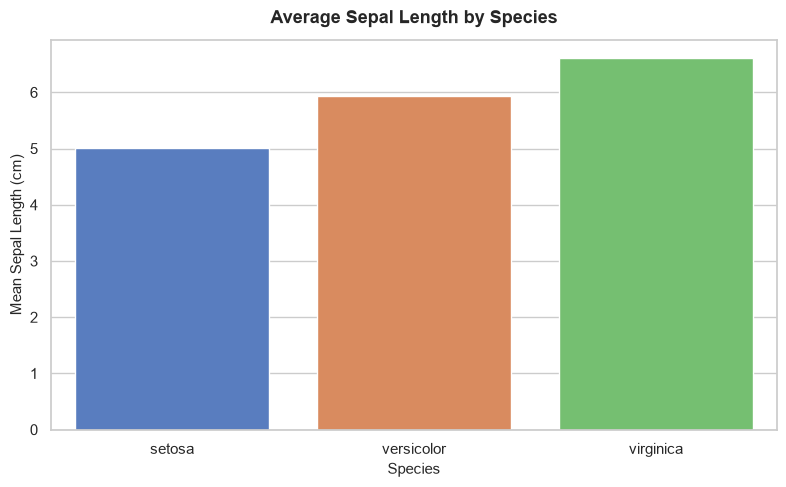

In [115]:
# Bar Plot (Species Comparison)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x=species_col,
    y=num_cols[0],
    palette="muted",
    estimator="mean",
    errorbar=None
)

plt.title(f"Average {num_cols[0].replace('_', ' ').title()} by Species", fontsize=13, weight="bold", pad=12)
plt.xlabel("Species", fontsize=11)
plt.ylabel(f"Mean {num_cols[0].replace('_', ' ').title()} (cm)", fontsize=11)

plt.tight_layout()
plt.savefig(f"{output_dir}/1_bar_plot.png", dpi=300)
plt.show()

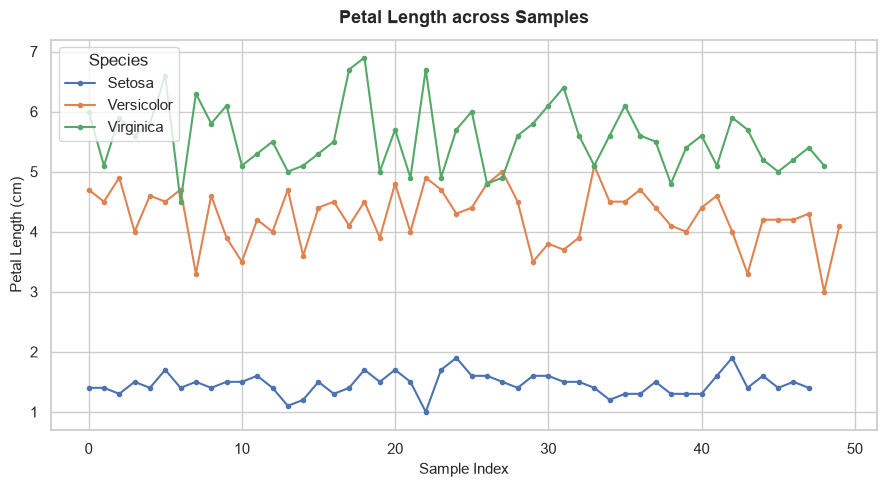

In [116]:

#  Line Chart (Sample Profiles / Index Trend)
plt.figure(figsize=(9, 5))
for species in df[species_col].unique():
    subset = df[df[species_col] == species].reset_index(drop=True)
    plt.plot(
        subset.index,
        subset[num_cols[2]],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=str(species).capitalize()
    )

plt.title(f"{num_cols[2].replace('_', ' ').title()} across Samples", fontsize=13, weight="bold", pad=12)
plt.xlabel("Sample Index", fontsize=11)
plt.ylabel(f"{num_cols[2].replace('_', ' ').title()} (cm)", fontsize=11)
plt.legend(title="Species", loc="upper left")

plt.tight_layout()
plt.savefig(f"{output_dir}/2_line_chart.png", dpi=300)
plt.show()

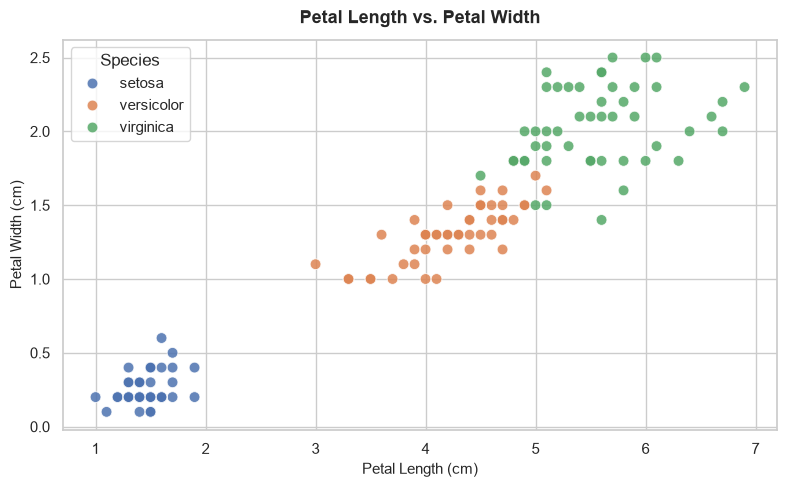

All plots successfully generated and saved to 'iris_visualizations/'.


In [117]:
# Scatter Plot (Feature Dimensions)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x=num_cols[2],  # Petal Length
    y=num_cols[3],  # Petal Width
    hue=species_col,
    palette="deep",
    s=60,
    alpha=0.85
)

plt.title(
    f"{num_cols[2].replace('_', ' ').title()} vs. {num_cols[3].replace('_', ' ').title()}",
    fontsize=13,
    weight="bold",
    pad=12
)
plt.xlabel(f"{num_cols[2].replace('_', ' ').title()} (cm)", fontsize=11)
plt.ylabel(f"{num_cols[3].replace('_', ' ').title()} (cm)", fontsize=11)
plt.legend(title="Species", loc="upper left")

plt.tight_layout()
plt.savefig(f"{output_dir}/3_scatter_plot.png", dpi=300)
plt.show()

print(f"All plots successfully generated and saved to '{output_dir}/'.")

## 2) Stock_price

In [118]:
#  Setup & Ingestion
os.makedirs("stock_visualizations", exist_ok=True)
sns.set_theme(style="whitegrid")

df = pd.read_csv("cleaned_stock_price_dataset.csv")

# Standardize columns and sort dates
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)


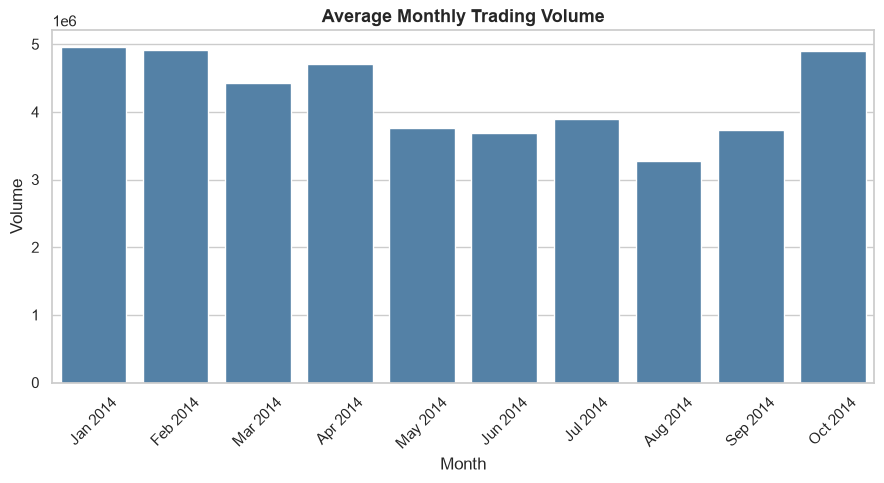

In [119]:
# Bar Plot (Monthly Trading Volume)
plt.figure(figsize=(9, 5))

# Group volume by month
monthly_vol = df.set_index("date").resample("ME")["volume"].mean().reset_index()
monthly_vol["month"] = monthly_vol["date"].dt.strftime("%b %Y")

sns.barplot(data=monthly_vol.head(10), x="month", y="volume", color="steelblue")
plt.title("Average Monthly Trading Volume", fontsize=13, weight="bold")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("stock_visualizations/1_bar_plot.png", dpi=300)
plt.show()

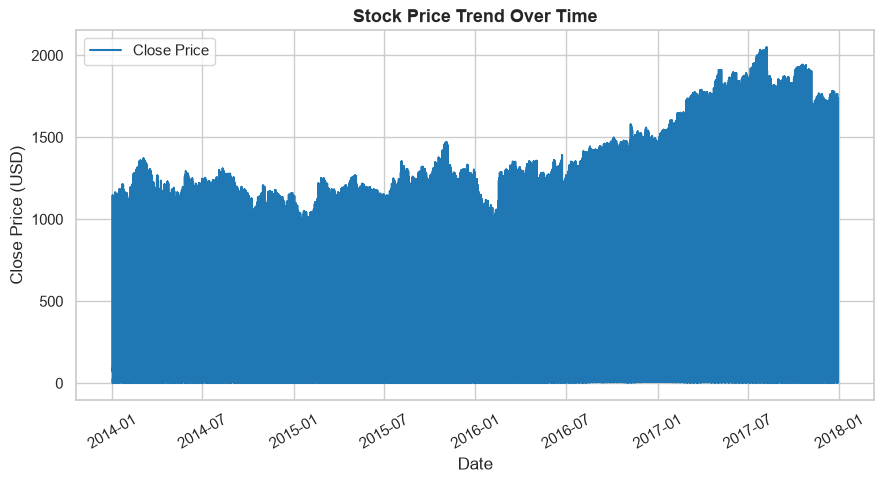

In [120]:
# Line Chart (Stock Price Trend)
plt.figure(figsize=(9, 5))

plt.plot(df["date"], df["close"], color="tab:blue", label="Close Price")
plt.title("Stock Price Trend Over Time", fontsize=13, weight="bold")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend(loc="upper left")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("stock_visualizations/2_line_chart.png", dpi=300)
plt.show()

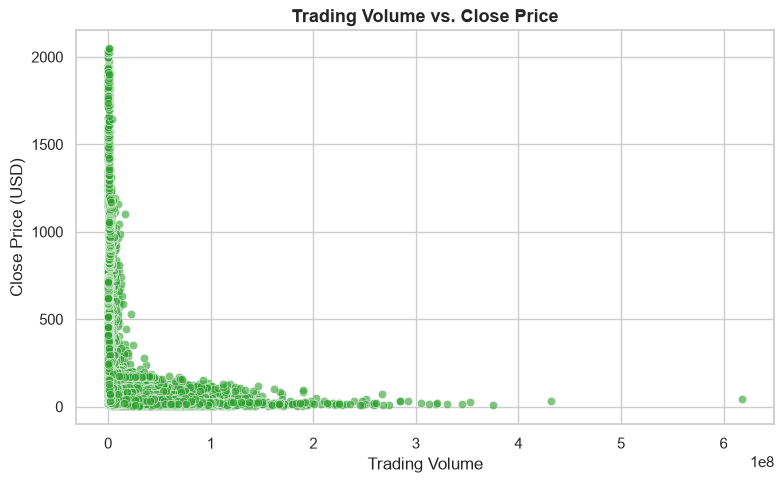

All plots saved to 'stock_visualizations/' folder.


In [121]:
# 4. Objective 3: Scatter Plot (Volume vs. Close Price)
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="volume", y="close", alpha=0.6, color="tab:green")
plt.title("Trading Volume vs. Close Price", fontsize=13, weight="bold")
plt.xlabel("Trading Volume")
plt.ylabel("Close Price (USD)")

plt.tight_layout()
plt.savefig("stock_visualizations/3_scatter_plot.png", dpi=300)
plt.show()

print("All plots saved to 'stock_visualizations/' folder.")

## 3) Sentiment

In [122]:
display(df_eda1.columns)

Index(['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='str')

In [123]:
df_eda1.shape

(710, 13)

In [124]:
platform_counts = df_eda1["Platform"].value_counts()
platform_counts

Platform
Instagram    251
Twitter      236
Facebook     223
Name: count, dtype: int64

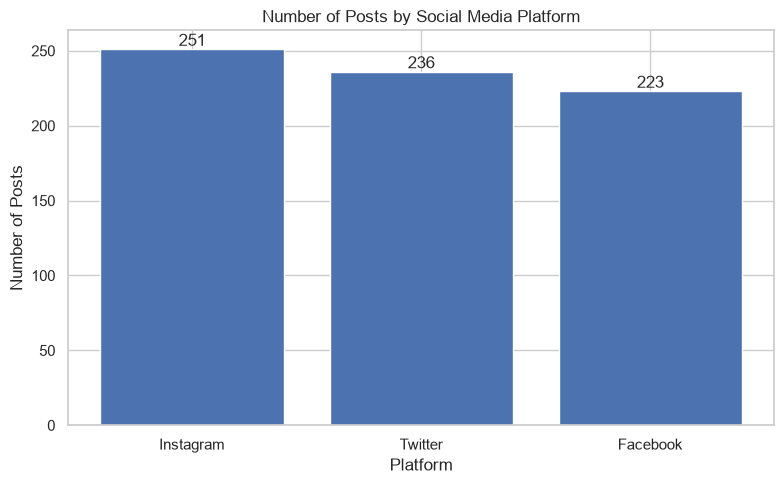

In [125]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    platform_counts.index,
    platform_counts.values
)

plt.title("Number of Posts by Social Media Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "posts_by_platform.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The bar chart compares the number of posts across the three social-media platforms. Instagram has the highest number of posts with 251, followed by Twitter with 236 and Facebook with 223. The distribution is relatively balanced across the three platforms.

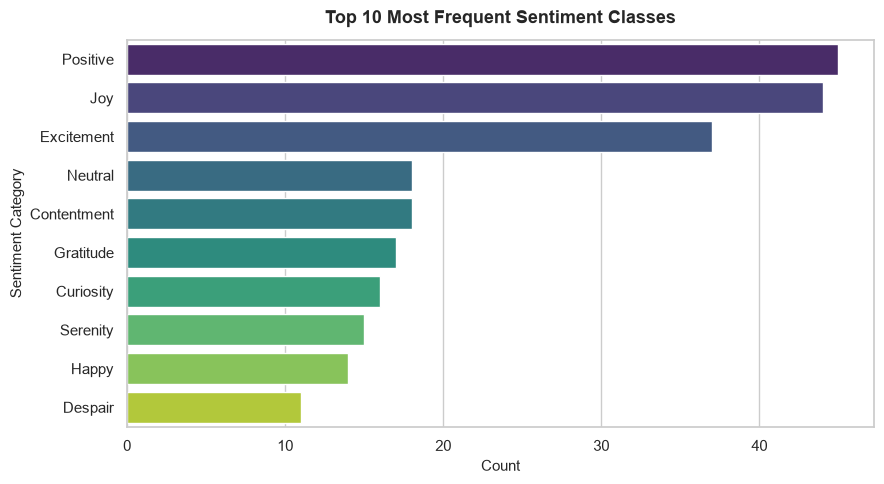

In [126]:
os.makedirs("sentiment_visualizations", exist_ok=True)
sns.set_theme(style="whitegrid")


df_eda1.columns = df_eda1.columns.str.strip().str.lower().str.replace(" ", "_")

sentiment_col = "sentiment" if "sentiment" in df_eda1.columns else "label"

# Get Top 10 sentiment categories
top_sentiments = df_eda1[sentiment_col].value_counts().nlargest(10).reset_index()
top_sentiments.columns = ["Sentiment", "Count"]

# Horizontal bar plot for clean, readable labels
plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_sentiments,
    x="Count",
    y="Sentiment",
    hue="Sentiment", # Assign 'Sentiment' to hue
    palette="viridis",
    legend=False      # Set legend to False
)

plt.title("Top 10 Most Frequent Sentiment Classes", fontsize=13, weight="bold", pad=12)
plt.xlabel("Count", fontsize=11)
plt.ylabel("Sentiment Category", fontsize=11)

plt.tight_layout()
plt.savefig("sentiment_visualizations/1_bar_plot_top10_sentiment.png", dpi=300)
plt.show()

In [127]:
monthly_likes = (
    df_eda1.groupby("month", observed=True)["likes"]
    .mean()
)

monthly_likes

month
Jan   37.94
Feb   41.24
Mar   42.61
Apr   42.80
May   42.09
Jun   47.34
Jul   49.60
Aug   43.83
Sep   41.61
Oct   41.72
Nov   43.87
Dec   41.95
Name: likes, dtype: float64

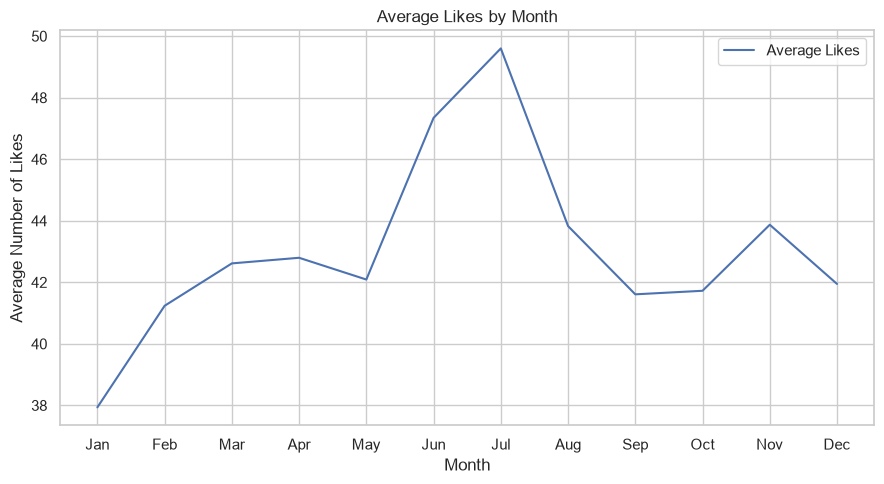

In [128]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_likes.index,
    monthly_likes.values,
    label="Average Likes"
)

plt.title("Average Likes by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Likes")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "sentiment_visualizations/average_likes_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

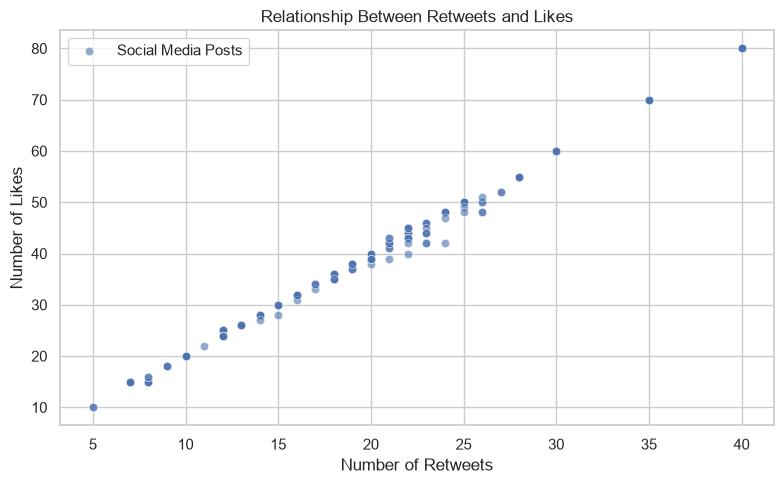

In [129]:
# Scatter plot: Retweets vs Likes
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_eda1,
    x="retweets",
    y="likes",
    alpha=0.6,
    label="Social Media Posts"
)

plt.title("Relationship Between Retweets and Likes")
plt.xlabel("Number of Retweets")
plt.ylabel("Number of Likes")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "sentiment_visualizations/retweets_vs_likes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()